<a href="https://colab.research.google.com/github/RA-1020/tiny-wfm-backbone/blob/main/phase0_shared_part_d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!ls -la "/content/drive/MyDrive/wfm-data/"

Mounted at /content/drive
total 88276
-rw------- 1 root root 90394152 Jul  5 08:26 radioml_subset.npz


In [3]:
!git clone https://github.com/RA-1020/tiny-wfm-backbone.git
%cd tiny-wfm-backbone

Cloning into 'tiny-wfm-backbone'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 18 (delta 2), reused 18 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), done.
Resolving deltas: 100% (2/2), done.
/content/tiny-wfm-backbone


In [4]:
!pip install timm wandb -q

In [5]:
import torch
import torch.nn as nn
import timm
import numpy as np
import wandb
from torch.utils.data import DataLoader, random_split
from dataset import RadioMLSpectrograms

wandb.login()   # or wandb.login(key="...") per last time, then clear the cell

device = torch.device("cuda")

full_ds = RadioMLSpectrograms("/content/drive/MyDrive/wfm-data/radioml_subset.npz")
print(len(full_ds), full_ds.classes)

# 80/20 train/val split, seeded for reproducibility (contract: seed=42)
g = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(full_ds, [0.8, 0.2], generator=g)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2)
print(len(train_ds), "train /", len(val_ds), "val")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ra-1020 (ra-10) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


12000 ['OOK', 'BPSK', 'QPSK', '8PSK', '16QAM', '64QAM', 'AM-DSB-WC', 'FM', 'GMSK', 'OQPSK']
9600 train / 2400 val


In [6]:
model = timm.create_model("vit_tiny_patch16_224", pretrained=True,
                          num_classes=10, in_chans=1).to(device)
print(sum(p.numel() for p in model.parameters())/1e6, "M params")

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

5.428042 M params


In [7]:
EPOCHS = 8
LR = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

run = wandb.init(project="tiny-wfm-backbone", name="stage-d-centralized-baseline",
                 config={"model": "vit_tiny_patch16_224", "pretrained": True,
                         "in_chans": 1, "lr": LR, "epochs": EPOCHS,
                         "data": "radioml_subset 10cls snr10-18"})

def evaluate():
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

for epoch in range(EPOCHS):
    model.train()
    running_loss = correct = total = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * y.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    val_acc = evaluate()
    wandb.log({"epoch": epoch, "train_loss": running_loss/total,
               "train_acc": correct/total, "val_acc": val_acc})
    print(f"epoch {epoch}: loss {running_loss/total:.3f} | train {correct/total:.1%} | val {val_acc:.1%}")

wandb.finish()

epoch 0: loss 0.856 | train 63.9% | val 76.3%
epoch 1: loss 0.499 | train 77.1% | val 73.8%
epoch 2: loss 0.383 | train 82.4% | val 83.9%
epoch 3: loss 0.260 | train 87.9% | val 87.6%
epoch 4: loss 0.192 | train 91.3% | val 88.9%
epoch 5: loss 0.154 | train 93.4% | val 87.8%
epoch 6: loss 0.136 | train 94.2% | val 87.8%
epoch 7: loss 0.120 | train 94.9% | val 89.1%


epoch,▁▂▃▄▅▆▇█
train_acc,▁▄▅▆▇███
train_loss,█▅▃▂▂▁▁▁
val_acc,▂▁▆▇█▇▇█
epoch,7
train_acc,0.94917
train_loss,0.12011
val_acc,0.89083


       OOK: 99.6%
      BPSK: 81.5%
      QPSK: 100.0%
      8PSK: 71.6%
     16QAM: 99.2%
     64QAM: 100.0%
 AM-DSB-WC: 100.0%
        FM: 100.0%
      GMSK: 77.4%
     OQPSK: 58.3%


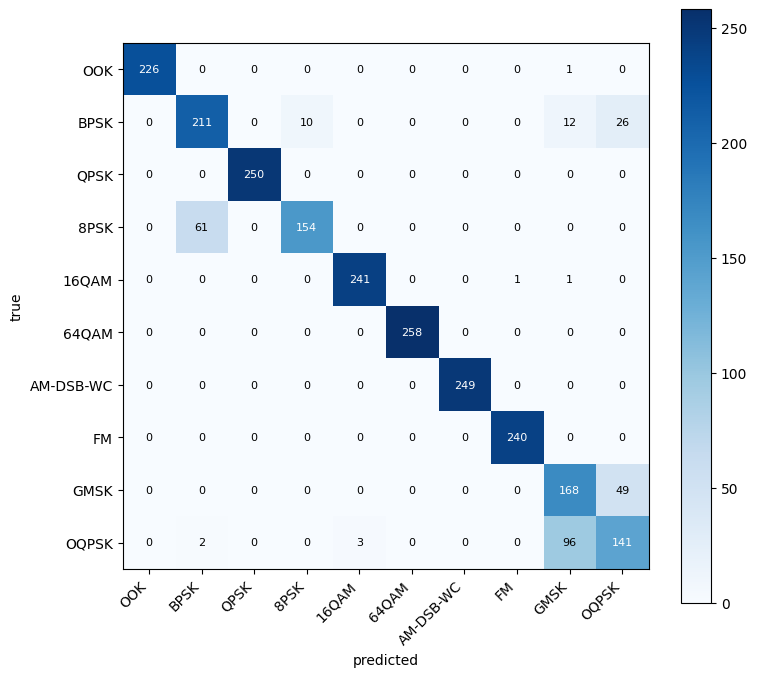

In [8]:
import matplotlib.pyplot as plt

model.eval()
C = torch.zeros(10, 10, dtype=torch.int32)
with torch.no_grad():
    for x, y in val_loader:
        pred = model(x.to(device)).argmax(dim=1).cpu()
        for t, p in zip(y, pred):
            C[t, p] += 1

per_class_acc = C.diag().float() / C.sum(dim=1).float()
for name, acc in zip(full_ds.classes, per_class_acc):
    print(f"{name:>10}: {acc:.1%}")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(C, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(full_ds.classes, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(full_ds.classes)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
for i in range(10):
    for j in range(10):
        ax.text(j, i, C[i, j].item(), ha="center", va="center",
                color="white" if C[i, j] > C.max()//2 else "black", fontsize=8)
plt.colorbar(im); plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

In [10]:
run = wandb.init(project="tiny-wfm-backbone", name="stage-d-confusion-matrix",
                 notes="confusion matrix for run stage-d-centralized-baseline")
wandb.log({"confusion_matrix": wandb.Image("confusion_matrix.png")})
wandb.finish()